<a href="https://colab.research.google.com/github/faisalkhan6ai-sketch/AI-ML-Internship-Tasks/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64
               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  890.000000  865.000000  858.000000   
mean   460.500000   53.510870  132.132404  199.130337  137.545665    0.878788   
std    265.725422    9.424685   19.066070  110.780810   25.926276    1.091226   
min      1.000000   28.000000    0.000000    0.000000   60.000000   -2.600000   
25%    230.750000   47.000000  120.000000  175.000000  120.000000    0.000000   
50%    460.500000   54.000000  130.000000  223.000000  140.000000    0.500000   
75%    690.250000   60.000000  140.000000  268.000000  157.000000    1.500000   
max    920.000000   77.000000  200.000000  603.000000  202.000000    6.200000   

 

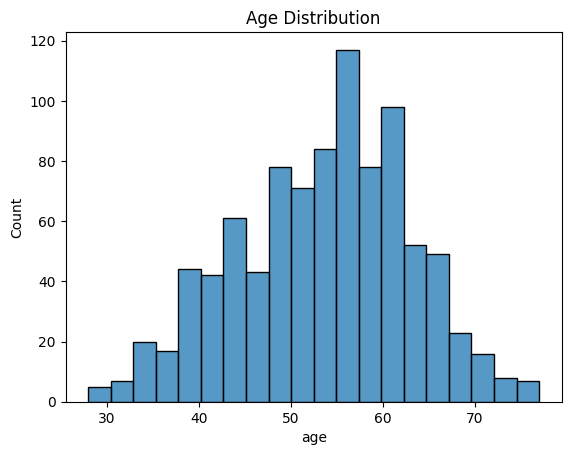

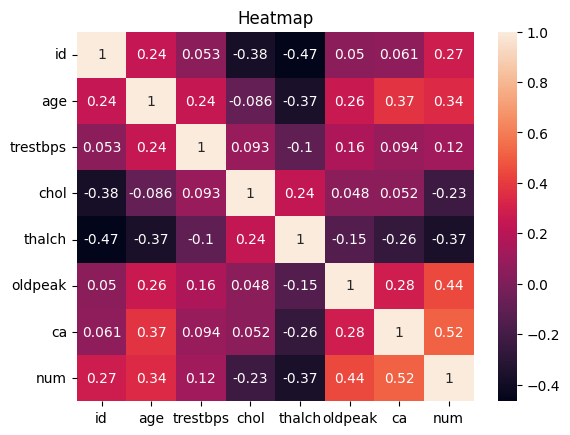

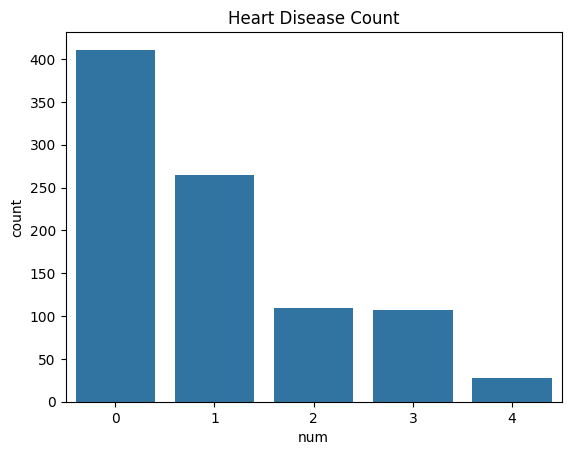

Accuracy: 58.06451612903226
Confusion Matrix:
 [[31  0  0  0  0]
 [12  0  0  3  0]
 [ 1  0  1  4  0]
 [ 2  2  0  4  0]
 [ 0  1  0  1  0]]
AUC Score: 78.70555327712103


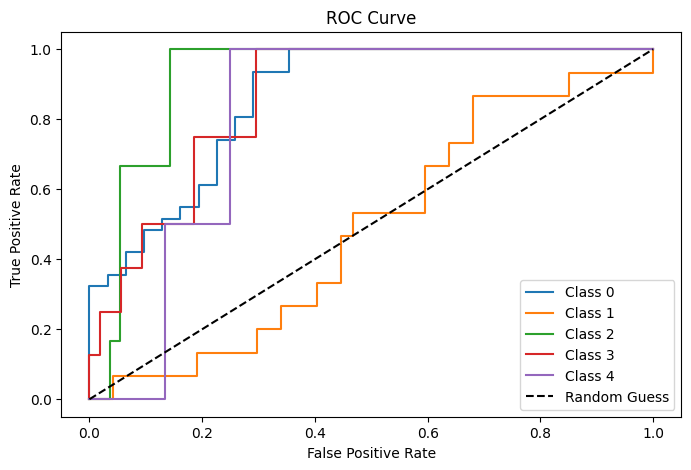


Feature Importance:
    Feature  Importance
5        ca    0.465276
4   oldpeak    0.408714
3    thalch    0.298764
2      chol    0.158277
0       age    0.144799
1  trestbps    0.082356


/tmp/ipykernel_2438/640284634.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


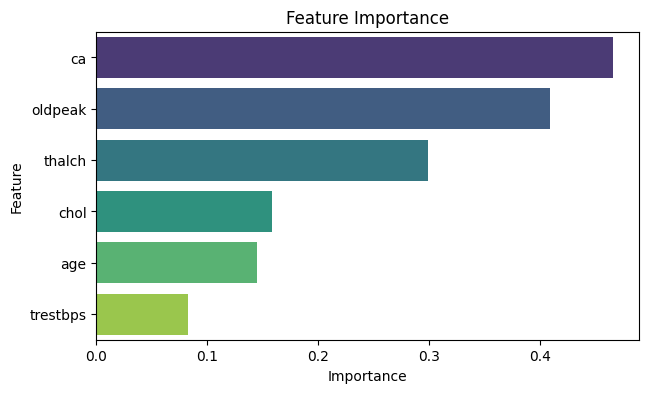

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, label_binarize

#Load Data
df = pd.read_csv("/content/heart_disease_uci.csv")

#EDA
print(df.isnull().sum())
print(df.describe())

sns.histplot(df['age'], bins=20)
plt.title("Age Distribution")
plt.show()

numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Heatmap")
plt.show()

sns.countplot(x='num', data=df)
plt.title("Heart Disease Count")
plt.show()

#Prepare Data
X = df[['age','trestbps','chol','thalch','oldpeak','ca']]
y = df['num']

clean = pd.concat([X, y], axis=1).dropna()
X = clean[['age','trestbps','chol','thalch','oldpeak','ca']]
y = clean['num']

#Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

#Train Model
model = LogisticRegression(max_iter=100000)
model.fit(X_train, y_train)

#Accuracy and Confusion Matrix
print("Accuracy:", accuracy_score(y_test, model.predict(X_test)) * 100)
print("Confusion Matrix:\n", confusion_matrix(y_test, model.predict(X_test)))
print("AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr') * 100)

#ROC Curve Plot
classes    = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)
y_prob     = model.predict_proba(X_test)

plt.figure(figsize=(8, 5))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {cls}")
plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#Feature Importance
feature_names = ['age','trestbps','chol','thalch','oldpeak','ca']
importance    = np.abs(model.coef_).mean(axis=0)

importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(7, 4))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Feature Importance")
plt.show()